In [1]:
# !export CUDA_VISIBLE_DEVICES=1
import torch
import torch.nn as nn
import os
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import pandas as pd

import wandb

from copy import deepcopy

from cmcrameri import cm


# Configure matplotlib to use LaTeX for r'' strings while keeping other text unchanged
mpl.rcParams.update({
    'text.usetex': True,          # Use LaTeX for r'' strings
    'font.family': 'sans-serif',  # Default font family for regular text
    'mathtext.fontset': 'dejavusans',  # Font for math not using r''
    'axes.formatter.use_mathtext': False  # Enable math text for tick labels
})

In [ ]:
from plot_utils import add_string_formatters_to_axes

In [2]:
api = wandb.Api()

In [ ]:
savedir = "RPL_figures/8_hRPL"  # change to your desired directory
if not os.path.exists(savedir):
    os.makedirs(savedir)

# Functions

In [ ]:
def extract_all_results(datasets, api=None):
    """ Extracts results from wandb runs for the specified datasets.
    Args:
        datasets: List of dataset names
    Returns:
        Nested dict: {dataset: {task: {area: {metric_type: [values]}}}}
    """
    if api is None:
        api = wandb.Api()
    
    # Initialize results dictionary
    results = {dataset: {} for dataset in datasets}
    
    # Debug counter
    processed_runs = 0
    acc_metrics_found = 0
    r2_metrics_found = 0
    
    runs = api.runs("hRPL", per_page=1000)
    
    for run in runs:
        try:
            *name_parts, seed_str = run.name.split('_')
            try:
                seed = int(seed_str)
            except ValueError:
                continue

            if name_parts[0].startswith('2025'):
                name_parts = name_parts[1:]  # Skip date prefix if present
                
            run_name = '_'.join(name_parts)
            
            # Sort datasets by length in descending order to match the longest prefix first
            sorted_datasets = sorted(datasets, key=len, reverse=True)
            matching_dataset = next((d for d in sorted_datasets if run_name.startswith(d)), None)
            
            if matching_dataset is None:
                continue
                
            # We only care about the 'pred' method now, so check if this is a pred run
            method_key = run_name[len(matching_dataset)+1:]
            if not method_key.startswith('pred'):
                continue
            
            if method_key not in results[matching_dataset]:
                results[matching_dataset][method_key] = {}
            last_metrics = run.summary
            
            # Process accuracy metrics with new naming convention
            val_metrics = {k: v for k, v in last_metrics.items() 
                         if k.startswith("Offline val. acc.") and v is not None}
            
            # Process R2 metrics with new naming convention
            val_r2_metrics = {}
            for k, v in last_metrics.items():
                if k.startswith("Offline sklearn regression test R2") and v is not None:
                    # Convert to new naming convention
                    new_key = k.replace("Offline sklearn regression test R2", "Offline val. R2")
                    val_r2_metrics[new_key] = v
                elif k.startswith("Offline val. R2") and v is not None:
                    # Keep existing R2 metrics
                    val_r2_metrics[k] = v
            
            # Increment counters
            if val_metrics:
                acc_metrics_found += 1
            if val_r2_metrics:
                r2_metrics_found += 1
            
            # Skip if no metrics found
            if not val_metrics and not val_r2_metrics:
                continue
            
            processed_runs += 1
            
            # Store accuracy metrics by task and area
            for key, value in val_metrics.items():
                # Parse task and area from the metric key
                # Format: "Online val. acc. (task), area X"
                if "(" not in key or "), area" not in key:
                    continue
                    
                task = key.split("(")[1].split(")")[0].strip()
                area = key.split("area ")[1].strip()
                
                # Initialize dictionaries if they don't exist
                if results[matching_dataset][method_key].get(task, None) is None:
                    results[matching_dataset][method_key][task] = {}
                if results[matching_dataset][method_key][task].get(area, None) is None:
                    results[matching_dataset][method_key][task][area] = {'acc': [], 'r2': []}
                
                # Store the accuracy value
                results[matching_dataset][method_key][task][area]['acc'].append(value)
            
            # Store R2 metrics by task and area
            for key, value in val_r2_metrics.items():
                # Parse task and area from the metric key
                # Format: "Regression val. R2 (task), area X"
                if "(" not in key or "), area" not in key:
                    continue
                    
                task = key.split("(")[1].split(")")[0]
                area = key.split("area ")[1].strip()
                
                # Initialize dictionaries if they don't exist
                if results[matching_dataset][method_key].get(task, None) is None:
                    results[matching_dataset][method_key][task] = {}
                if results[matching_dataset][method_key][task].get(area, None) is None:
                    results[matching_dataset][method_key][task][area] = {'acc': [], 'r2': []}
                
                # Store the R2 value
                results[matching_dataset][method_key][task][area]['r2'].append(value)
            
        except Exception as e:
            print(f"Error processing run {run.name}: {e}")
            continue
    
    print(f"Processed {processed_runs} runs")
    print(f"Found accuracy metrics in {acc_metrics_found} runs")
    print(f"Found R2 metrics in {r2_metrics_found} runs")
    
    return results

def results_to_dataframe(results):
    # Create lists to store the data
    rows = []
    
    # Iterate through the nested dictionary
    for dataset in results:
        for method in results[dataset]:
            for task in results[dataset][method]:
                for area in results[dataset][method][task]:
                    # Get metrics for this combination
                    metrics = results[dataset][method][task][area]
                    
                    # Maximum number of seeds in either acc or r2
                    max_seeds = max(len(metrics['acc']), len(metrics['r2']))
                    
                    # Create a row for each seed
                    for seed in range(max_seeds):
                        row = {
                            'dataset': dataset,
                            'method': method,
                            'task': task,
                            'area': area,
                            'seed': seed,
                        }
                        
                        # Add accuracy if available for this seed
                        if seed < len(metrics['acc']):
                            row['accuracy'] = metrics['acc'][seed]
                        
                        # Add r2 if available for this seed
                        if seed < len(metrics['r2']):
                            row['r2'] = metrics['r2'][seed]
                            
                        rows.append(row)
    
    # Convert to DataFrame
    df = pd.DataFrame(rows)
    return df

# Example usage:
datasets = ['animals_greedy_cts_noiseOnTop0.1',
            'animals_greedy_cts_noiseOnTop0.1_freeze',
            ]

# Extract results with the new format
results = extract_all_results(datasets=datasets)

# Convert to DataFrame
results_df = results_to_dataframe(results)

Processed 24 runs
Found accuracy metrics in 24 runs
Found R2 metrics in 24 runs


In [ ]:
def plot_metrics_by_area(results, datasets, methods, task, metric='acc', figsize=(4, 3), ylabel=None, colors=['gray'], save_path=None,
                         title=None, average_tasks=False, tasks_to_average=None, baseline_value=None, legend_labels=None,
                         show_legend=False, loc_legend='upper left', ylim=None):
    """
    Plot metrics over different areas for a specific dataset and task,
    averaging over seeds and showing standard deviation as a shaded area.
    
    Args:
        results: The nested dictionary from extract_all_results
        datasets: The dataset names to plot
        task: The task name to plot (ignored if average_tasks is True)
        metric: Which metric to plot ('acc' or 'r2')
        figsize: Figure size as a tuple (width, height) in inches
        ylabel: Custom y-axis label (defaults to 'Accuracy' or 'R²' based on metric)
        colors: Colors for the lines and shaded areas
        save_path: Optional path to save the figure
        title: Optional title for the plot
        average_tasks: Whether to average multiple tasks (if True, tasks_to_average must be provided)
        tasks_to_average: List of task names to average (required if average_tasks is True)
        baseline_value: Optional float to draw a horizontal baseline labeled 'E2E'
        legend_labels: Optional list of labels for the legend
        show_legend: Whether to show the legend
        loc_legend: Location of the legend (default is 'upper left')
        
    Returns:
        matplotlib Figure and Axes objects
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import matplotlib as mpl
    import seaborn as sns
    
    # Set default font sizes
    mpl.rcParams.update({'font.size': 8,
                         'axes.titlesize': 8,
                         'axes.labelsize': 8,
                         'xtick.labelsize': 8,
                         'ytick.labelsize': 8,
                         'legend.fontsize': 8})
    
    # Create figure and axes
    fig, ax = plt.subplots(figsize=figsize)
    
    for i, dataset in enumerate(datasets):

        # Check if dataset exists
        if dataset not in results:
            raise ValueError(f"Dataset '{dataset}' not found in results")
        
        for j, method in enumerate(methods):
            # Check if method exists
            if method not in results[dataset]:
                raise ValueError(f"Method '{method}' not found in dataset '{dataset}'")
        
            # Get color for this dataset
            color = colors[(j + i * len(methods)) % len(colors)]

            # Get legend label if provided
            if legend_labels is not None:
                label = legend_labels[i * len(methods) + j]
            else:
                label = f"{dataset} ({method})"
    
            # Handle task averaging
            if average_tasks:
                if not tasks_to_average:
                    raise ValueError("tasks_to_average must be provided when average_tasks is True")
                
                # Validate tasks
                valid_tasks = [t for t in tasks_to_average if t in results[dataset][method]]
                if not valid_tasks:
                    raise ValueError(f"None of the provided tasks {tasks_to_average} were found in dataset '{dataset}'")
                
                # Find common areas across all tasks
                common_areas = set()
                for t in valid_tasks:
                    common_areas.update(results[dataset][method][t].keys())
                
                # Sort areas numerically if possible
                try:
                    areas = sorted(common_areas, key=int)
                except ValueError:
                    areas = sorted(common_areas)
                
                # Prepare data for plotting
                x_values = [int(area)+1 for area in areas]
                avg_means = []
                avg_stds = []
                
                for area in areas:
                    # Collect all values from all tasks for this area
                    all_values = []
                    
                    for t in valid_tasks:
                        if area in results[dataset][method][t] and metric in results[dataset][method][t][area]:
                            values = results[dataset][method][t][area][metric]
                            if values:
                                all_values.extend(values)
                    
                    if all_values:
                        avg_means.append(np.mean(all_values))
                        avg_stds.append(np.std(all_values))
                    else:
                        avg_means.append(np.nan)
                        avg_stds.append(np.nan)
                
                # Convert to numpy arrays
                y_means = np.array(avg_means)
                y_stds = np.array(avg_stds)
            
            else:
                # Single task plotting (original behavior)
                if task not in results[dataset][method]:
                    raise ValueError(f"Task '{task}' not found in dataset '{dataset}'")
                
                # Get available areas and convert to integers for sorting
                areas = list(results[dataset][method][task].keys())
                try:
                    # Sort areas numerically (they should be strings of integers)
                    areas = sorted(areas, key=int)
                except ValueError:
                    # If areas can't be converted to integers, sort them as strings
                    areas = sorted(areas)
                
                # Prepare data for plotting
                x_values = [int(area)+1 for area in areas]
                y_means = []
                y_stds = []
                
                for area in areas:
                    # Get all values for this metric across seeds
                    values = results[dataset][method][task][area][metric]
                    if not values:
                        # Skip if no values available
                        y_means.append(np.nan)
                        y_stds.append(np.nan)
                        continue
                        
                    # Calculate mean and standard deviation
                    y_means.append(np.mean(values))
                    y_stds.append(np.std(values))
                
                # Convert to numpy arrays for easier manipulation
                y_means = np.array(y_means)
                y_stds = np.array(y_stds)
            
            # Plot mean line
            ax.plot(x_values, y_means, marker='o', color=color, linewidth=1.5, markersize=4, label=label, zorder=-i)
            
            # Add shaded area for standard deviation
            ax.fill_between(x_values, y_means - y_stds, y_means + y_stds, color=color, alpha=0.4)
    
    # Add baseline if provided
    if baseline_value is not None:
        ax.axhline(y=baseline_value, color='black', linestyle='-', linewidth=0.5, label='RPL')
    
    # Set labels and title
    ax.set_xlabel('Level')
    
    # Set y-label based on metric if not provided
    if ylabel is None:
        if metric == 'acc':
            ylabel = 'Accuracy'
        elif metric == 'r2':
            ylabel = 'R²'
        else:
            ylabel = metric.capitalize()
    
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, fontsize=10)

    if ylim is not None:
        ax.set_ylim(ylim)

    
    # Add legend if baseline is provided
    if show_legend:
        ax.legend(fontsize=8, frameon=False, loc=loc_legend, 
              handlelength=2.0, handletextpad=0.5, labelspacing=0.5)

    # Add string formatters to axes
    add_string_formatters_to_axes(ax)
    ax.set_xticks([1,6])
    ax.set_xticklabels([1,6])
    
    # reduce spacing between x label and axis
    ax.xaxis.set_label_coords(0.5, -0.3)

    # Adjust layout
    sns.despine()
    
    # Save figure if path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=False)
    
    return fig, ax

# Compute corrected orientations for greedy models
Skip this section if you have already ran the notebook once.

In [ ]:
from harpl.scripts.utils import get_data_specs, prepare_data
from harpl.networks.utils import prepare_model, additional_data_process

In [ ]:
input_size, num_classes = get_data_specs(dataset="animals",
                                        target_label="multitask",
                                        dsprites_seqtype="xy_drift",
                                        flatten_images=False,
                                        spritevid_num_sprites=8)

(train_loader, train_sampler, 
    val_loader, val_sampler,
        test_loader, test_sampler,
    ) = prepare_data(
            dataset="animals",
            data_input_dir="../datasets",
            seq_len=32,
            num_workers=0,
            batch_size=128,
            val_batch_size=128,
            grayscale=False,
            target_label="multitask",
            spritevid_max_sprites=8,
            spritevid_noise_type="gaussian",
            spritevid_noise_level=0.1,
            sprite_noise_on_top=True,
            spritevid_discretize_latents=False,

        )

Computing normalization values using 10000 samples...
Computed normalization values - mean: tensor([0.5009, 0.4962, 0.4950], device='cuda:0'), std: tensor([0.1234, 0.1192, 0.1209], device='cuda:0')


In [9]:
seq_len = 32
batch_size = 128
enc_dims = [32 for _ in range(6)]
ctx_dims = [512 for _ in range(6)]

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
# models (all models are for animals with 6-layer arch preserving spatial dim)
CHECKPOINTS_DIR = "../checkpoints"
model_names = {
    "full": "animals_greedy_cts_noiseOnTop0.1_pred",
    "last_only": "animals_greedy_cts_noiseOnTop0.1_freeze_pred",
}

In [ ]:
preprocess, postprocess = additional_data_process("dsprites", flatten_enc_output=True)
n_in_channels = 3

fully_trained_model_list = []
last_only_model_list = []

for i, seed in enumerate([1,2,3]):
    for key, name in model_names.items():
        model = deepcopy(prepare_model(
            n_areas=6,
            input_size=input_size,
            encoder_kind="conv2d",
            use_bn_enc=True,
            enc_n_layers=1,
            enc_kernel_size=[(5,5) for _ in range(6)],
            enc_stride=[(2,2), (2,2), (1,1), (1,1), (1,1), (1,1)],
            enc_padding=[(2,2) for _ in range(6)],
            enc_dim=enc_dims,
            flatten_enc_output=True,
            integrator_kind="lstm",
            ctx_dim=ctx_dims,
            predictor_kind="mlp",
            pred_hidden_dim=[512 for _ in range(6)],
            pred_n_hidden_layers=1,
            pred_steps=1,
            return_full_features=True,
            preprocess=preprocess,
            postprocess=postprocess,
            n_in_channels=n_in_channels,
            frozen_areas=[False for _ in range(6)],
            state_dict=torch.load(os.path.join(CHECKPOINTS_DIR, f"{name}_{seed}", "model_final.pt")),
        )).to(device)
        for param in model.parameters():
            param.requires_grad = False
        if key == "full":
            fully_trained_model_list.append(model)
        else:
            last_only_model_list.append(model)

In [ ]:
for seed in [1,2,3]:
    last_only_model_list[seed-1].load_state_dict(
        torch.load(os.path.join(CHECKPOINTS_DIR, f"{model_names['last_only']}_{seed}", "model_final.pt"))
    )

In [ ]:
from readout_utils import compute_corrected_orientation_regressor_projections

In [16]:
def extract_data_greedy(model, j, device, data_loader, seq_len, repr_dim):
    batch_size = data_loader.batch_size
    num_samples = len(data_loader.dataset)

    representations = torch.zeros(num_samples, seq_len, repr_dim).to(device)
    gt_orientations_raw = torch.zeros(num_samples, seq_len, 1).to(device)
    sprite_labels_raw = torch.zeros(num_samples, 1, dtype=torch.long).to(device)

    current_sample_idx = 0
    with torch.no_grad():
        for i, (data, labels) in enumerate(data_loader):
            data = data.to(device)
            reprs_ = model(data)[1][j]
            
            start_idx = i * batch_size
            end_idx_batch = min(batch_size, num_samples - start_idx)
            end_idx = start_idx + end_idx_batch

            if end_idx > representations.shape[0]:
                end_idx_batch = representations.shape[0] - start_idx
                end_idx = representations.shape[0]

            sprite_labels_raw[start_idx:end_idx] = labels[0][:end_idx_batch, 0].to(device).unsqueeze(1)
            gt_orientations_raw[start_idx:end_idx] = labels[4][:end_idx_batch].to(device) * 2 * np.pi
            representations[start_idx:end_idx] = reprs_[:end_idx_batch]
                
            current_sample_idx = end_idx

    if current_sample_idx < representations.shape[0]:
        representations = representations[:current_sample_idx]
        gt_orientations_raw = gt_orientations_raw[:current_sample_idx]
        sprite_labels_raw = sprite_labels_raw[:current_sample_idx]

    representations = representations.reshape(-1, repr_dim)
    gt_orientations_raw = gt_orientations_raw.reshape(-1, 1)
    sprite_labels_raw = sprite_labels_raw.repeat(1, seq_len).reshape(-1, 1)

    return representations, gt_orientations_raw, sprite_labels_raw


In [17]:
corrected_orientations = {
    "full": {
        "orientation": np.zeros((3, 6)),
        "sin": np.zeros((3, 6)),
        "cos": np.zeros((3, 6)),
    },
    "last_only": {
        "orientation": np.zeros((3, 6)),
        "sin": np.zeros((3, 6)),
        "cos": np.zeros((3, 6)),
    }
}

In [18]:
for i in range(3):
    for j in range(6):
        # Get representations and labels
        reprs_train, gt_orientations_raw_train, sprite_labels_raw_train = extract_data_greedy(
            fully_trained_model_list[i], j, device, train_loader, seq_len, ctx_dims[j]
        )
        reprs_test, gt_orientations_raw_test, sprite_labels_raw_test = extract_data_greedy(
            fully_trained_model_list[i], j, device, test_loader, seq_len, ctx_dims[j]
        )
        # Normalize representations
        train_mean = reprs_train.mean(axis=0)
        train_std = reprs_train.std(axis=0)
        reprs_train = (reprs_train - train_mean) / (train_std + 1e-8)
        reprs_test = (reprs_test - train_mean) / (train_std + 1e-8)

        _,_,_,_,_,_, r2_sin, r2_cos, clf_acc,_,_ = compute_corrected_orientation_regressor_projections(
            reprs_train, gt_orientations_raw_train, sprite_labels_raw_train, 
            reprs_test, gt_orientations_raw_test, sprite_labels_raw_test, device=device,
        )
        corrected_orientations["full"]["orientation"][i, j] = clf_acc
        corrected_orientations["full"]["sin"][i, j] = r2_sin
        corrected_orientations["full"]["cos"][i, j] = r2_cos
        del reprs_train, gt_orientations_raw_train, sprite_labels_raw_train
        del reprs_test, gt_orientations_raw_test, sprite_labels_raw_test

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

In [19]:
for i in range(3):
    for j in range(6):
        # Get representations and labels
        reprs_train, gt_orientations_raw_train, sprite_labels_raw_train = extract_data_greedy(
            last_only_model_list[i], j, device, train_loader, seq_len, ctx_dims[j]
        )
        reprs_test, gt_orientations_raw_test, sprite_labels_raw_test = extract_data_greedy(
            last_only_model_list[i], j, device, test_loader, seq_len, ctx_dims[j]
        )

        # Normalize representations
        train_mean = reprs_train.mean(axis=0)
        train_std = reprs_train.std(axis=0)
        reprs_train = (reprs_train - train_mean) / (train_std + 1e-8)
        reprs_test = (reprs_test - train_mean) / (train_std + 1e-8)

        _,_,_,_,_,_, r2_sin, r2_cos, clf_acc,_,_ = compute_corrected_orientation_regressor_projections(
            reprs_train, gt_orientations_raw_train, sprite_labels_raw_train, 
            reprs_test, gt_orientations_raw_test, sprite_labels_raw_test, device=device,
        )
        corrected_orientations["last_only"]["orientation"][i, j] = clf_acc
        corrected_orientations["last_only"]["sin"][i, j] = r2_sin
        corrected_orientations["last_only"]["cos"][i, j] = r2_cos
        del reprs_train, gt_orientations_raw_train, sprite_labels_raw_train
        del reprs_test, gt_orientations_raw_test, sprite_labels_raw_test

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

...

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

Corrected Orientation Training:   0%|          | 0/5000 [00:00<?, ?it/s]

In [20]:
corrected_orientations

{'full': {'orientation': array([[0.04051107, 0.04630534, 0.08572591, 0.12869466, 0.17101237,
          0.20611979],
         [0.04072266, 0.05017904, 0.07944336, 0.13147786, 0.15784505,
          0.19002279],
         [0.03925781, 0.04895833, 0.09012044, 0.13911133, 0.17503255,
          0.17965495]]),
  'sin': array([[0.03196061, 0.08064371, 0.26537718, 0.37646366, 0.48932602,
          0.50261713],
         [0.03083228, 0.07550398, 0.28530454, 0.43040776, 0.48512516,
          0.5204735 ],
         [0.03425452, 0.08101951, 0.25580204, 0.41763486, 0.51317314,
          0.53984884]]),
  'cos': array([[0.02712165, 0.04789323, 0.27483218, 0.44155465, 0.53089735,
          0.57776714],
         [0.02448306, 0.07486708, 0.16743771, 0.41285981, 0.49125585,
          0.53157996],
         [0.02770717, 0.07770809, 0.27843035, 0.44665874, 0.50850754,
          0.50666329]])},
 'last_only': {'orientation': array([[0.02898763, 0.02851562, 0.03027344, 0.02973633, 0.02856445,
          0.03821615]

In [ ]:
np.savez(
    "../checkpoints/hRPL_corrected_orientations_noisy.npz",
    corrected_orientations=corrected_orientations,
)

# Plotting

In [13]:
import matplotlib
matplotlib.rc('text', usetex=True)
matplotlib.rc('text.latex', preamble=r'\usepackage{amsmath}')

In [ ]:
corrected_orientations_file = np.load('../checkpoints/hRPL_corrected_orientations_noisy.npz', allow_pickle=True)
corrected_orientations = corrected_orientations_file["corrected_orientations"].item()

In [11]:
results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_orientation"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}
results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_sin"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}
results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_cos"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}

results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_orientation"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}
results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_sin"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}
results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_cos"] = {str(i): {'acc': [], 'r2': []} for i in range(6)}

for i in range(6):
    results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_orientation"][str(i)]['acc'] = corrected_orientations['full']['orientation'][:, i].tolist()
    results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_sin"][str(i)]['r2'] = corrected_orientations['full']['sin'][:, i].tolist()
    results["animals_greedy_cts_noiseOnTop0.1"]["pred"]["corrected_cos"][str(i)]['r2'] = corrected_orientations['full']['cos'][:, i].tolist()

    results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_orientation"][str(i)]['acc'] = corrected_orientations['last_only']['orientation'][:, i].tolist()
    results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_sin"][str(i)]['r2'] = corrected_orientations['last_only']['sin'][:, i].tolist()
    results["animals_greedy_cts_noiseOnTop0.1_freeze"]["pred"]["corrected_cos"][str(i)]['r2'] = corrected_orientations['last_only']['cos'][:, i].tolist()

Text(0.5, -0.3, 'Circuit')

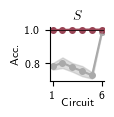

In [ ]:
fig, ax = plot_metrics_by_area(
    results, 
    datasets=['animals_greedy_cts_noiseOnTop0.1', 'animals_greedy_cts_noiseOnTop0.1_freeze'],
    methods=['pred'],
    task='sprite_idx',
    metric='acc', 
    figsize=(0.7, 0.7), 
    ylabel='Acc.', 
    colors=['#994455', '#AAAAAA'],
    average_tasks=False, 
    title=r'$S$',
    baseline_value=1.0,
)
ax.set_xticks([1,6])
ax.set_xticklabels([1,6])
ax.set_xlabel('Circuit')
fig.savefig(os.path.join(savedir, 'animals_greedy_spriteid.pdf'), dpi=300, bbox_inches='tight', transparent=True)

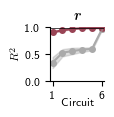

In [15]:
fig, ax = plot_metrics_by_area(
    results, 
    datasets=['animals_greedy_cts_noiseOnTop0.1', 'animals_greedy_cts_noiseOnTop0.1_freeze'],
    methods=['pred'],
    task=None,
    metric='r2', 
    figsize=(0.7, 0.7), 
    ylabel=r'$R^2$',
    colors=['#994455', '#AAAAAA'],
    average_tasks=True, 
    tasks_to_average=['x-position', 'y-position', 'z-position'],
    title=r'$\boldsymbol{r}$',
    ylim=(0.0,1.0),
    baseline_value=(0.99349 + 0.99468 + 0.98536) / 3,
)
ax.set_xticks([1,6])
ax.set_xticklabels([1,6])
ax.set_xlabel('Circuit')
fig.savefig(os.path.join(savedir, 'animals_greedy_position_with_z.pdf'), dpi=300, bbox_inches='tight', transparent=True)

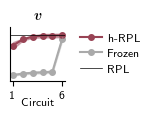

In [16]:
fig, ax = plot_metrics_by_area(
    results, 
    datasets=['animals_greedy_cts_noiseOnTop0.1', 'animals_greedy_cts_noiseOnTop0.1_freeze'],
    methods=['pred'],
    task=None,
    metric='r2', 
    ylim=(-0.1,1.0),
    figsize=(0.7, 0.7), 
    ylabel=r'$R^2$',
    colors=['#994455', '#AAAAAA'],
    average_tasks=True, 
    tasks_to_average=['x-velocity', 'y-velocity', 'z-velocity'],
    title=r'$\boldsymbol{v}$',
    baseline_value=(0.86074 + 0.86045 + 0.82410) / 3,
    legend_labels=['h-RPL', 'Frozen'],
    show_legend=True,
    loc_legend=(1.2, 0.05),
)
ax.set_xticks([1,6])
ax.set_xticklabels([1,6])
ax.yaxis.set_visible(False)
ax.set_xlabel('Circuit')
fig.savefig(os.path.join(savedir, 'animals_greedy_velocity_with_z.pdf'), dpi=300, bbox_inches='tight', transparent=True)

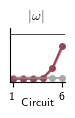

In [ ]:
fig, ax = plot_metrics_by_area(
    results, 
    datasets=['animals_greedy_cts_noiseOnTop0.1', 'animals_greedy_cts_noiseOnTop0.1_freeze'],
    methods=['pred'],
    task='rotation_speed',
    metric='r2', 
    ylim=(-0.1,1.0),
    figsize=(0.7, 0.7), 
    ylabel=r'$R^2$',
    colors=['#994455', '#AAAAAA'],
    average_tasks=False, 
    title=r'$|\omega|$',
    baseline_value=0.88089, # was not converged
)
ax.yaxis.set_visible(False)

ax.set_xlabel('Circuit')
fig.savefig(os.path.join(savedir, 'animals_greedy_omega.pdf'), dpi=300, bbox_inches='tight', transparent=True)

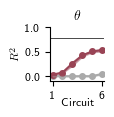

In [ ]:
fig, ax_trig = plot_metrics_by_area(
    results, 
    datasets=['animals_greedy_cts_noiseOnTop0.1', 'animals_greedy_cts_noiseOnTop0.1_freeze'],
    methods=['pred'],
    task=None,
    metric='r2', 
    figsize=(0.7, 0.7), 
    ylim=(-0.1,1.0),
    ylabel=r'$R^2$',
    colors=['#994455', '#AAAAAA'],
    average_tasks=True, 
    tasks_to_average=['corrected_sin', 'corrected_cos'],
    title=r'$\theta$',
    baseline_value=(0.76508 + 0.77183) / 2,
)
ax_trig.set_xlabel('Circuit')
ax_trig.set_yticks([0.0,0.5,1.0])

fig.savefig(os.path.join(savedir, 'animals_greedy_trig.pdf'), dpi=300, bbox_inches='tight', transparent=True)

## Autocorrelations

In [ ]:
def vector_autocorr_summaries_torch(X: torch.Tensor):
    """
    Compute scalar summary measures of normalized autocorrelation for vector time series in PyTorch.

    Args:
        X : torch.Tensor of shape (batch, seq_length, dim)

    Returns:
        dict with keys "trace", "frobenius", "canonical_corr"
            Each is tensor of shape (seq_length,) with measures at lags 0..T-1
    """
    B, T, D = X.shape
    Xc = X - X.mean(dim=1, keepdim=True)  # mean-center per batch
    print(B, T, D)

    # Gamma(0): covariance at lag 0 (average over batch)
    Gamma0 = torch.stack([(x.T @ x) / T for x in Xc]).mean(dim=0)

    # diagonal variance scaling for correlation matrices
    diag = torch.diag(Gamma0)
    inv_sqrt_var = torch.diag(1.0 / torch.sqrt(diag + 1e-12))  # safe eps

    traces, frobs, ccrs = [], [], []

    for tau in range(T):
        # autocovariance at lag tau
        Gamma_tau = torch.stack(
            [(x[:T-tau].T @ x[tau:]) / (T - tau) for x in Xc]
        ).mean(dim=0)

        # ----- normalized correlation matrix for trace/frob -----
        R_tau = inv_sqrt_var @ Gamma_tau @ inv_sqrt_var

        traces.append(torch.trace(R_tau) / D)
        frobs.append(torch.linalg.norm(R_tau, ord="fro"))

        # ----- canonical corr using Gamma0 normalization -----
        try:
            A = torch.linalg.pinv(Gamma0) @ Gamma_tau @ torch.linalg.pinv(Gamma0) @ Gamma_tau.T
            eigvals = torch.linalg.eigvals(A).real
            eigvals = torch.clamp(eigvals, min=0)
            ccrs.append(torch.sqrt(torch.max(eigvals)))
        except RuntimeError:
            ccrs.append(torch.tensor(float("nan"), device=X.device))

    return {
        "trace": torch.stack(traces),
        "frobenius": torch.stack(frobs),
        "canonical_corr": torch.stack(ccrs),
    }

In [ ]:
autocorr_results = []

for j in range(6):
    reprs_test , _, _ = extract_data_greedy(
        fully_trained_model_list[0], j, device, test_loader, seq_len, ctx_dims[j], flatten_seqdim=False
    )

    # Normalize representations
    reprs_test = (reprs_test - reprs_test.mean(axis=0)) / (reprs_test.std(axis=0) + 1e-8)

    # Compute autocorrelations
    autocorr_metrics = vector_autocorr_summaries_torch(reprs_test[:,4:])
    autocorr_results.append(autocorr_metrics)

3968 28 512
3968 28 512
3968 28 512
3968 28 512
3968 28 512
3968 28 512


In [ ]:
autocorr_results_control = []

for j in range(6):
    reprs_test , _, _ = extract_data_greedy(
        last_only_model_list[0], j, device, test_loader, seq_len, ctx_dims[j], flatten_seqdim=False
    )

    # Normalize representations
    reprs_test = (reprs_test - reprs_test.mean(axis=0)) / (reprs_test.std(axis=0) + 1e-8)

    # Compute autocorrelations
    autocorr_metrics = vector_autocorr_summaries_torch(reprs_test[:,4:])
    autocorr_results_control.append(autocorr_metrics)

3968 28 512
3968 28 512
3968 28 512
3968 28 512
3968 28 512
3968 28 512


In [ ]:
labels = {"trace": "Trace", "frobenius": "Autocorrelation", "canonical_corr": "Canonical Correlation"}

In [ ]:
def plot_metrics_vs_layer(autocorr_results, metric="trace", cmap="plasma", logscale=False):
    n_layers = len(autocorr_results)
    seq_len = len(autocorr_results[0][metric])
    colors = plt.cm.get_cmap(cmap, seq_len)

    # stack into (layers, seq_len)
    M = np.stack([res[metric].cpu().numpy() for res in autocorr_results], axis=0)

    fig, ax = plt.subplots(figsize=(8,5))
    for tau in range(seq_len):
        ax.plot(range(n_layers), M[:, tau], color=colors(tau), label=f"lag {tau}")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, seq_len-1))
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("time lag")
    ax.set_xlabel("layer")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs layer (all lags)")
    if logscale:
        ax.set_yscale("log")
    fig.tight_layout()
    sns.despine()
    plt.show()

In [ ]:
def plot_metrics_vs_lag(autocorr_results, metric="trace", cmap="viridis", logscale=False, show_colorbar=False):
    n_layers = len(autocorr_results)
    seq_len = len(autocorr_results[0][metric])
    colors = plt.cm.get_cmap(cmap, n_layers)

    fig, ax = plt.subplots(figsize=(1.5,1.0))
    for j, res in enumerate(autocorr_results):
        ax.plot(np.arange(seq_len), res[metric].cpu().numpy(),
                color=colors(j), label=f"Circuit {j}")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(1, n_layers))
    if show_colorbar:
        cbar = fig.colorbar(sm, ax=ax, ticks=range(n_layers))
        cbar.set_label("Circuit", fontsize=8)
    ax.set_xlabel("Time lag", fontsize=8)
    ax.set_ylabel(labels.get(metric, metric), fontsize=8)
    if logscale:
        ax.set_yscale("log")
    sns.despine()
    plt.show()


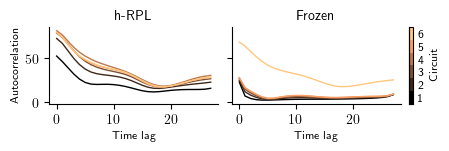

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(4.38, 1.4), sharey=True, constrained_layout=True)
n_layers = len(autocorr_results)
seq_len = len(autocorr_results[0]["frobenius"])
cmap = "copper"

cmap = plt.cm.copper
cmap_list = cmap(np.linspace(0, 1, n_layers))
colors = mpl.colors.ListedColormap(cmap_list)

for j, res in enumerate(autocorr_results):
    axs[0].plot(np.arange(seq_len), res["frobenius"].cpu().numpy(),
                color=colors(j), label=f"Circuit {j}", lw=1)

for j, res in enumerate(autocorr_results_control):
    axs[1].plot(np.arange(seq_len), res["frobenius"].cpu().numpy(),
                color=colors(j), label=f"Circuit {j}", lw=1)
    
axs[0].set_xlabel("Time lag", fontsize=8)
axs[0].set_ylabel("Autocorrelation", fontsize=8)
axs[0].set_title("h-RPL", fontsize=10)
axs[1].set_xlabel("Time lag", fontsize=8)
axs[1].set_title("Frozen", fontsize=10)

bounds = np.arange(n_layers+1)-0.5
norm = mpl.colors.BoundaryNorm(boundaries=bounds, ncolors=n_layers)
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=colors), ax=axs[1], ticks=range(n_layers))
cbar.set_label("Circuit", fontsize=8)
# remove minor ticks
cbar.ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
cbar.ax.tick_params(labelsize=8, length=0)
cbar.set_ticks(np.arange(n_layers), labels=[str(i+1) for i in range(n_layers)])

sns.despine()

fig.savefig(os.path.join(savedir, 'suppl_fig_animals_autocorr.pdf'), dpi=300, bbox_inches='tight', transparent=True)